In [1]:
# %%
# Importação das bibliotecas necessárias
# Manipulação de dados
import os
import glob
import ctypes
import site
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


import pywt  # Biblioteca para transformacoes wavelet
import keras_tuner as kt
# Pré-processamento
from sklearn.preprocessing import MinMaxScaler

import keras

from keras import backend as K


# Componentes do modelo Seq2Seq com Atenção
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Bidirectional, Dropout, Dense, Concatenate, TimeDistributed, Attention
from tensorflow.keras.layers import (
    Conv1D,
    BatchNormalization,
    Activation,
    Add,
    LayerNormalization,
    Flatten,
    Reshape,
    SpatialDropout1D,
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# Métricas de avaliação
from sklearn.metrics import mean_absolute_error, mean_squared_error


# Otimizar alocacao de memoria GPU - reduz fragmentacao
os.environ['TF_GPU_ALLOCATOR'] = 'cuda_malloc_async'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '1'  # Reduce TensorFlow logging verbosity

# Garante runtime de GPU no Arch Linux (cuSOLVER e libs CUDA via wheel)
def configure_tensorflow_gpu_runtime():
    """Configura paths CUDA do venv e pre-carrega bibliotecas antes do import do TensorFlow."""
    current_ld = os.environ.get('LD_LIBRARY_PATH', '')
    candidate_dirs = []

    for sp in site.getsitepackages():
        candidate_dirs.extend(glob.glob(os.path.join(sp, 'nvidia', '*', 'lib')))

    if 'VIRTUAL_ENV' in os.environ:
        candidate_dirs.extend(
            glob.glob(
                os.path.join(
                    os.environ['VIRTUAL_ENV'],
                    'lib',
                    'python*',
                    'site-packages',
                    'nvidia',
                    '*',
                    'lib',
                )
            )
        )

    valid_dirs = []
    for lib_dir in candidate_dirs:
        if os.path.isdir(lib_dir) and lib_dir not in valid_dirs:
            valid_dirs.append(lib_dir)

    if valid_dirs:
        merged = ':'.join(valid_dirs)
        os.environ['LD_LIBRARY_PATH'] = f"{merged}:{current_ld}" if current_ld else merged

        # Pre-carrega libs CUDA para evitar falha de resolucao dinamica no kernel do VS Code
        preload_libs = [
            'libcudart.so.12',
            'libcublas.so.12',
            'libcudnn.so.9',
            'libcusolver.so.11',
        ]
        for lib_name in preload_libs:
            for lib_dir in valid_dirs:
                lib_path = os.path.join(lib_dir, lib_name)
                if os.path.exists(lib_path):
                    try:
                        ctypes.CDLL(lib_path, mode=ctypes.RTLD_GLOBAL)
                    except OSError:
                        pass
                    break

    return valid_dirs

cuda_lib_dirs = configure_tensorflow_gpu_runtime()
print('CUDA lib dirs found:', len(cuda_lib_dirs))
from tcn import TCN

import tensorflow as tf
print('TensorFlow:', tf.__version__)
print('Python:', os.environ.get('VIRTUAL_ENV', 'sem VIRTUAL_ENV'))
print('GPUs:', tf.config.list_physical_devices('GPU'))

I0000 00:00:1787310346.471543  320764 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


CUDA lib dirs found: 11
TensorFlow: 2.21.0
Python: /home/zino/projects/wind-speed-forescasting/.venv
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
import sys
from pathlib import Path
from tensorflow.keras.utils import plot_model

import matplotlib.dates as mdates
import pandas as pd
import keras_tuner as kt

project_root = Path.cwd().resolve()
if not (project_root / "data" / "dataset.csv").exists():
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.models.s2s_lstm_bi_wrapper import S2SLSTMBidirectionalWrapper
from src.utils import wavelet_denoising

dataset = pd.read_csv(project_root / "data" / "dataset.csv")
dataset["id"] = pd.to_datetime(dataset["id"], format="mixed")
dataset = dataset.sort_values("id").set_index("id")

train_ratio = 0.75
val_ratio = 0.20

train_end = int(len(dataset) * train_ratio)
val_end = train_end + int(len(dataset) * val_ratio)

train_df = dataset.iloc[:train_end].copy()
val_df = dataset.iloc[train_end:val_end].copy()
test_df = dataset.iloc[val_end:].copy()

input_steps = 72
output_steps = 36

wrapper = S2SLSTMBidirectionalWrapper().prepare(
    train_df,
    val_df,
    input_steps=input_steps,
    output_steps=output_steps,
    target_col="ws100_wavelet",
    denoise=["ws100"],
)


hp = kt.HyperParameters()
model = wrapper.build(hp)
plot_model(wrapper.model, to_file='model_structure.png', show_trainable=True, show_shapes=True, show_layer_names=True, expand_nested=True, dpi=300)
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6),
    ModelCheckpoint('../models/best_model.h5.keras', monitor='val_loss', save_best_only=True)
]
history = wrapper.fit(epochs=100, batch_size=32, verbose=1, callbacks=callbacks, use_validation=True)

#print("Rows:", len(dataset))
#print("Train/val/test:", len(train_df), len(val_df), len(test_df))
#print("Final training loss:", history.history["loss"][-1])

I0000 00:00:1787310349.225759  320764 gpu_process_state.cc:208] Using CUDA malloc Async allocator for GPU: 0
I0000 00:00:1787310349.226871  320764 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4117 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1660, pci bus id: 0000:01:00.0, compute capability: 7.5


Epoch 1/100


I0000 00:00:1787310353.663877  321888 cuda_dnn.cc:461] Loaded cuDNN version 92000


174/174 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - loss: 0.0783 - mae: 0.1173 - val_loss: 0.0042 - val_mae: 0.0481 - learning_rate: 0.0064
Epoch 2/100
174/174 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.0036 - mae: 0.0444 - val_loss: 0.0022 - val_mae: 0.0353 - learning_rate: 0.0064
Epoch 3/100
174/174 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0019 - mae: 0.0321 - val_loss: 9.8049e-04 - val_mae: 0.0233 - learning_rate: 0.0064
Epoch 4/100
168/174 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0011 - mae: 0.0243

KeyboardInterrupt: 

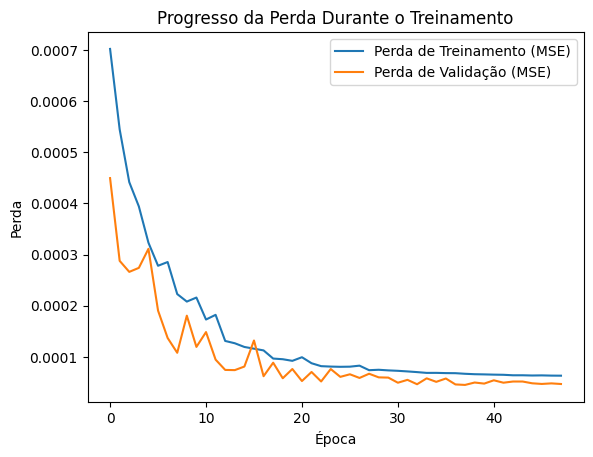

In [ ]:

plt.plot(history.history['loss'][5:], label='Perda de Treinamento (MSE)')
plt.plot(history.history['val_loss'][5:], label='Perda de Validação (MSE)') #pula o primeiro pois a tcn tem perda alta na primeira época
plt.xlabel('Época')
plt.ylabel('Perda')
plt.legend()
plt.title('Progresso da Perda Durante o Treinamento')
plt.savefig('../images/training_loss.png', dpi=300)
plt.show()

In [ ]:
forecast_df = dataset.copy()
predictions, actuals = wrapper.rolling_forecast(forecast_df, test_start=val_end)

Starting rolling forecast from index 7182 to 7526


In [ ]:
forecast_index = forecast_df.index[val_end + output_steps : val_end + output_steps - 1 + len(actuals)]
predictions = predictions.reshape(-1)[1:]
actuals = actuals.reshape(-1)

Predictions shape: (343,)
                            expected  predicted  old_predictions
id                                                              
2021-11-06 05:29:59.999997  7.049589   7.023461         7.545625
2021-11-06 05:40:00.000001  6.976737   6.947638         7.015099
2021-11-06 05:49:59.999996  6.912985   6.884265         6.976718
2021-11-06 06:00:00.000000  6.870333   6.844269         6.936406
2021-11-06 06:10:00.000004  6.812312   6.783152         6.911392


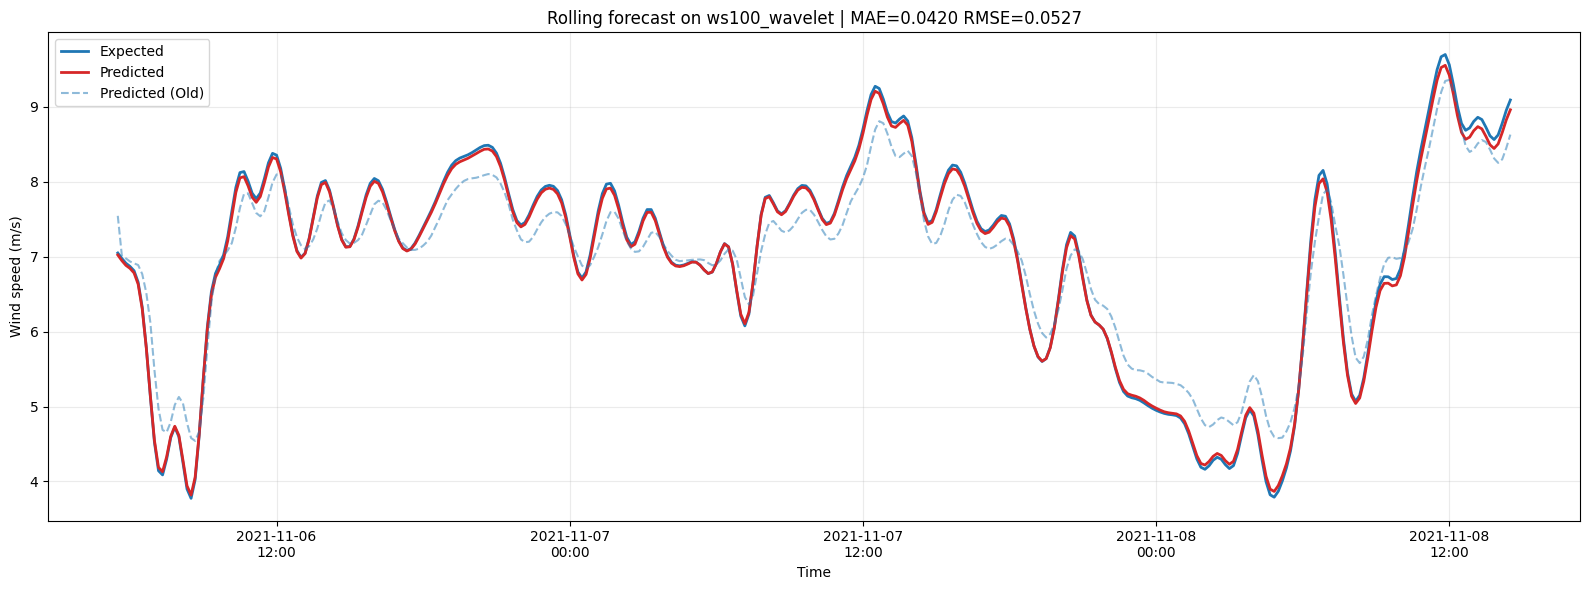

In [ ]:
print(f"Predictions shape: {predictions.shape}")
old_predictions_df = pd.read_csv(project_root / "data" / "old_prediction.csv")
old_predictions = old_predictions_df['predictions'].values
old_predictions = old_predictions.reshape(-1)
#print(f"Old predictions shape: {old_predictions_df.shape}")
#print(old_predictions_df.head())
#print(predictions.head())


mae = mean_absolute_error(actuals[:-1], predictions)
rmse = np.sqrt(mean_squared_error(actuals[:-1], predictions))

results = pd.DataFrame(
    {
        "expected": actuals[:-1],
        "predicted": predictions,
        "old_predictions": old_predictions[:len(predictions)]
    },
    index=forecast_index,
)

print(results.head())

fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(forecast_index, actuals[:-1], label="Expected", color="#1f77b4", linewidth=2)
ax.plot(forecast_index, predictions, label="Predicted", color="#d62728", linewidth=2)
ax.plot(forecast_index, old_predictions[:len(predictions)], label="Predicted (Old)", color="#1f77b4", linestyle='dashed', alpha=0.5)
ax.set_title(f"Rolling forecast on ws100_wavelet | MAE={mae:.4f} RMSE={rmse:.4f}")
ax.set_xlabel("Time")
ax.set_ylabel("Wind speed (m/s)")
ax.grid(alpha=0.25)
ax.legend()
ax.xaxis.set_major_locator(mdates.AutoDateLocator(minticks=4, maxticks=8))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d\n%H:%M"))
plt.setp(ax.get_xticklabels(), rotation=0, ha="center")
plt.tight_layout()
plt.show()

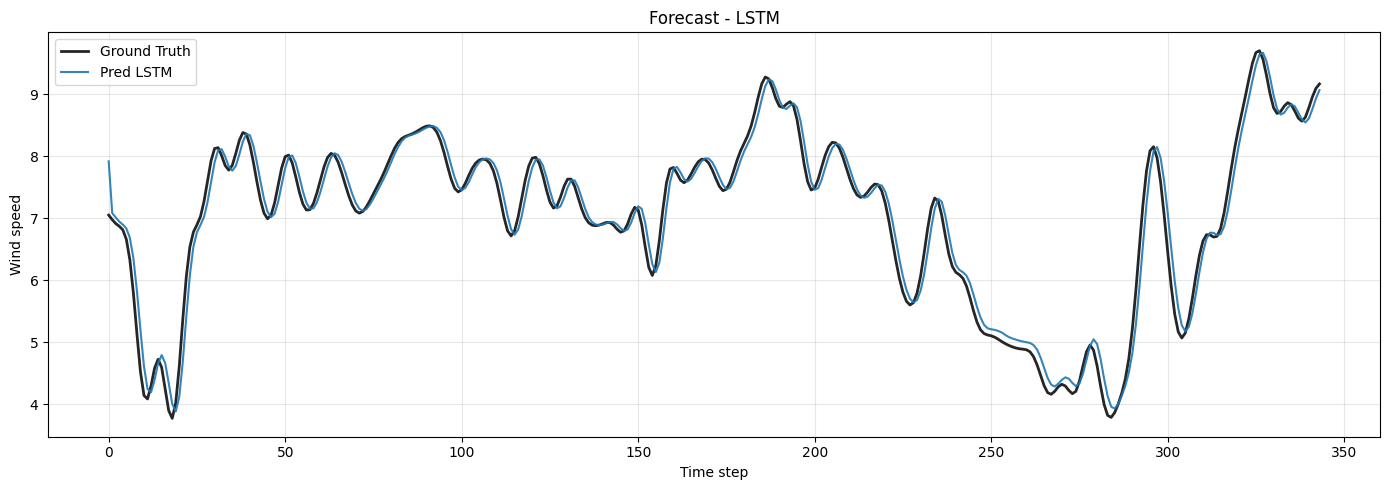

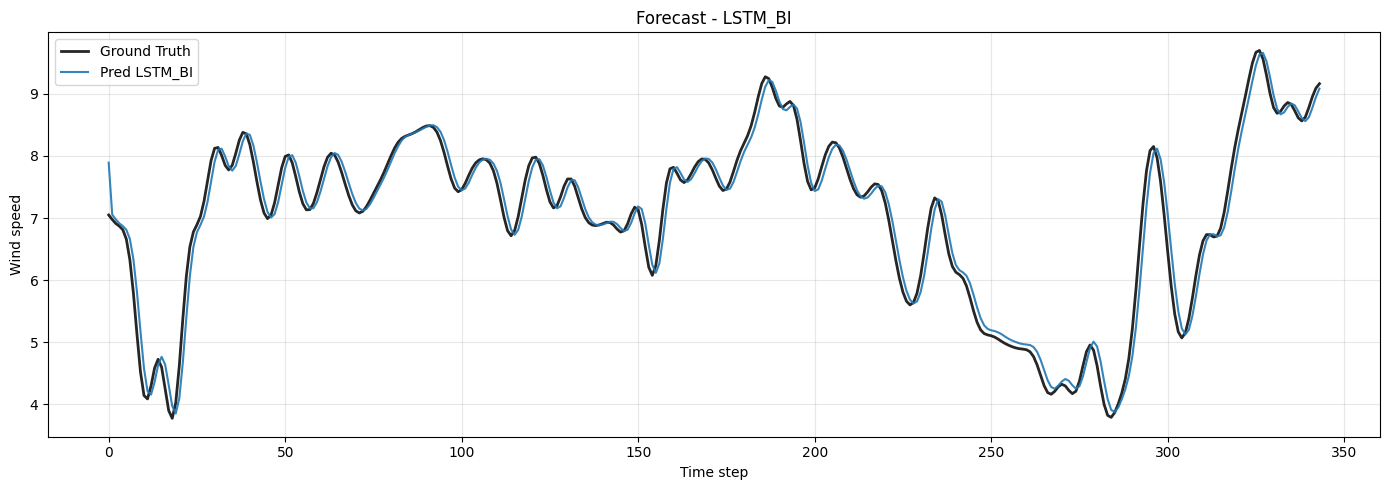

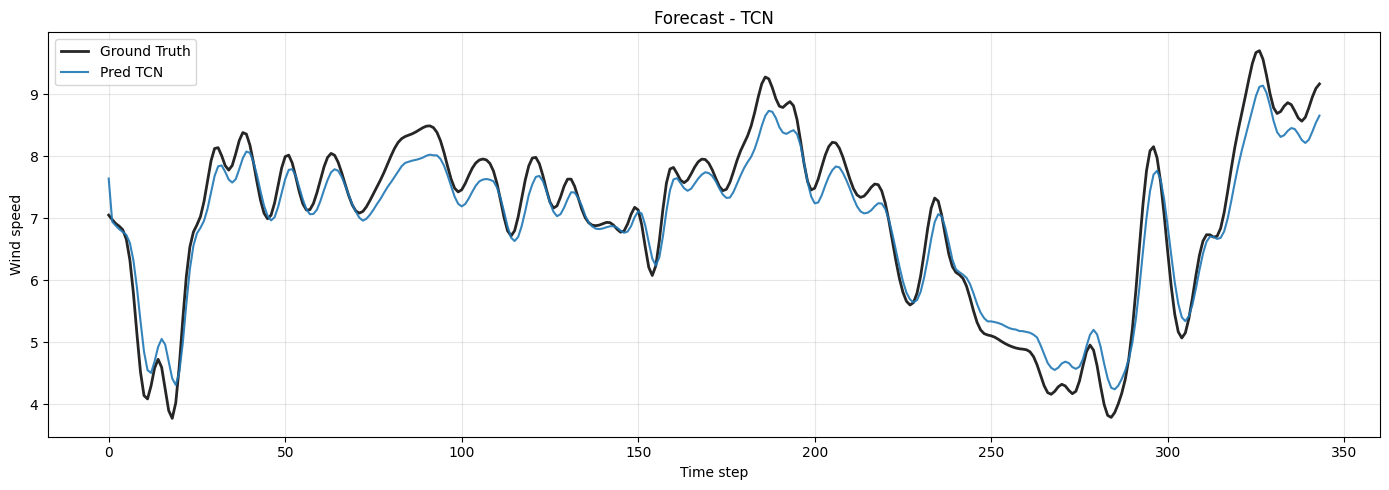

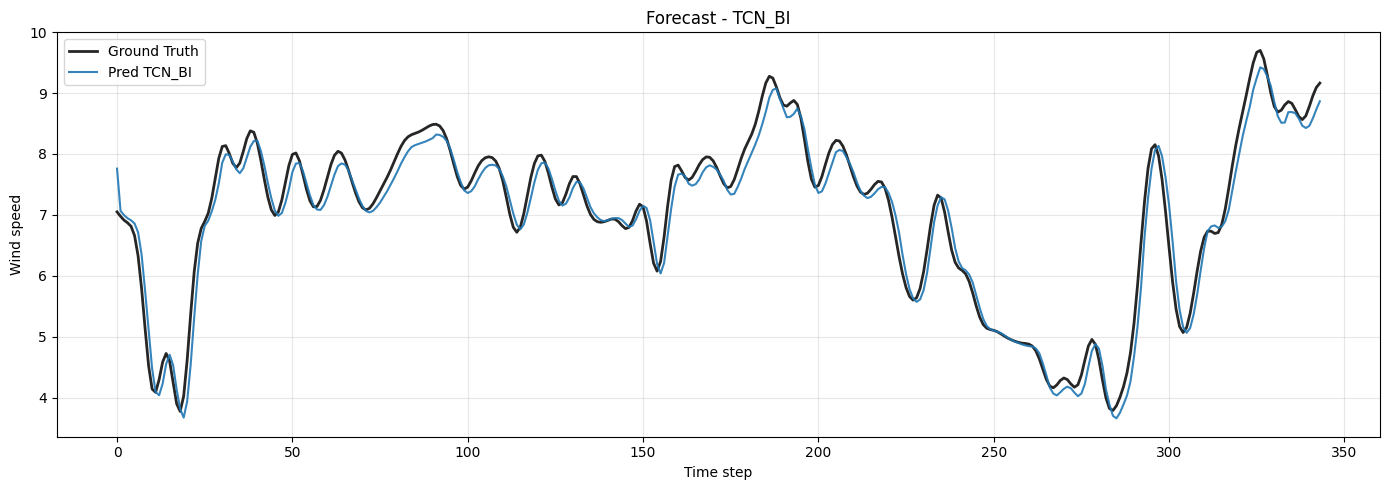

In [ ]:
# Added: load predictions from all models and plot one chart per model
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

project_root = Path.cwd().resolve()
if not (project_root / "data" / "results").exists():
    project_root = project_root.parent

model_files = {
    "LSTM": project_root / "data" / "results" / "wfo_optuna" / "Seq2Seq_LSTM" / "predictions.csv",
    "LSTM_BI": project_root / "data" / "results" / "wfo_optuna" / "Seq2Seq_LSTM_Bidirectional" / "predictions.csv",
    "TCN": project_root / "data" / "results" / "wfo_optuna" / "Seq2Seq_TCN" / "predictions.csv",
    "TCN_BI": project_root / "data" / "results" / "wfo_optuna" / "Seq2Seq_TCN_Bidirectional" / "predictions.csv",
    "TRANSFORMER": project_root / "data" / "results" / "wfo_optuna" / "Seq2Seq_Transformer_PreLN" / "predictions.csv",
}

results = {}
for model_name, file_path in model_files.items():
    if not file_path.exists():
        raise FileNotFoundError(f"Missing predictions file for {model_name}: {file_path}")
    df = pd.read_csv(file_path)
    if "prediction" not in df.columns or "actual" not in df.columns:
        raise ValueError(f"{file_path} must contain columns: prediction, actual")
    results[model_name] = df[["actual", "prediction"]].reset_index(drop=True)

min_len = min(len(df) for df in results.values())
for model_name in results:
    results[model_name] = results[model_name].iloc[:min_len]

for model_name, df in results.items():
    plt.figure(figsize=(14, 5))
    plt.plot(df["actual"].to_numpy(), label="Ground Truth", color="black", linewidth=2, alpha=0.85)
    plt.plot(df["prediction"].to_numpy(), label=f"Pred {model_name}", alpha=0.9)
    plt.title(f"Forecast - {model_name}")
    plt.xlabel("Time step")
    plt.ylabel("Wind speed")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


In [ ]:
# Análise detalhada: métricas de erro e de tempo por modelo
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

model_dirs = {
    "LSTM": project_root / "data" / "results" / "wfo_optuna" / "Seq2Seq_LSTM",
    "LSTM_BI": project_root / "data" / "results" / "wfo_optuna" / "Seq2Seq_LSTM_Bidirectional",
    "TCN": project_root / "data" / "results" / "wfo_optuna" / "Seq2Seq_TCN",
    "TCN_BI": project_root / "data" / "results" / "wfo_optuna" / "Seq2Seq_TCN_Bidirectional",
    "TRANSFORMER": project_root / "data" / "results" / "wfo_optuna" / "Seq2Seq_Transformer_PreLN",
}


def compute_detailed_metrics(actual, prediction):
    error = actual - prediction
    abs_error = np.abs(error)
    mape = np.mean(abs_error / np.maximum(np.abs(actual), 1e-8)) * 100
    return {
        "MAE": mean_absolute_error(actual, prediction),
        "MSE": mean_squared_error(actual, prediction),
        "RMSE": np.sqrt(mean_squared_error(actual, prediction)),
        "MAPE (%)": mape,
        "R²": r2_score(actual, prediction),
        "Max Error": np.max(abs_error),
        "Bias (média do erro)": np.mean(error),
        "Std do Erro": np.std(error),
        "P90 |Erro|": np.percentile(abs_error, 90),
        "P95 |Erro|": np.percentile(abs_error, 95),
        "P99 |Erro|": np.percentile(abs_error, 99),
        "Correlação": np.corrcoef(actual, prediction)[0, 1],
    }


detailed_metrics = {}
predictions_data = {}
for model_name, model_dir in model_dirs.items():
    df = pd.read_csv(model_dir / "predictions.csv")
    with (model_dir / "metrics.json").open(encoding="utf-8") as handle:
        meta = json.load(handle)
    actual = df["actual"].to_numpy()
    prediction = df["prediction"].to_numpy()
    stats = compute_detailed_metrics(actual, prediction)
    stats["test_samples"] = meta["test_samples"]
    stats["train_epochs"] = meta["train_epochs"]
    stats["prediction_time_sec"] = meta["prediction_time_sec"]
    stats["per_sample_time_ms"] = meta["prediction_time_sec"] / meta["test_samples"] * 1000
    detailed_metrics[model_name] = stats
    predictions_data[model_name] = {"actual": actual, "prediction": prediction}

error_columns = [
    "MAE", "MSE", "RMSE", "MAPE (%)", "R²", "Max Error",
    "Bias (média do erro)", "Std do Erro", "P90 |Erro|", "P95 |Erro|", "P99 |Erro|", "Correlação",
]
time_columns = ["prediction_time_sec", "per_sample_time_ms", "test_samples", "train_epochs"]

print("=== Estatísticas de erro por modelo ===")
print(pd.DataFrame(detailed_metrics).T[error_columns].to_string(float_format=lambda v: f"{v:,.4f}"))
print()
print("=== Estatísticas de tempo por modelo ===")
print(pd.DataFrame(detailed_metrics).T[time_columns].to_string(float_format=lambda v: f"{v:,.4f}"))


In [ ]:
# Parâmetros da busca Optuna: carrega best_trial.json da otimização para cada modelo
import json as _json

optuna_dirs = {
    "LSTM": project_root / "data" / "results" / "optuna" / "Seq2Seq_LSTM",
    "LSTM_BI": project_root / "data" / "results" / "optuna" / "Seq2Seq_LSTM_Bidirectional",
    "TCN": project_root / "data" / "results" / "optuna" / "Seq2Seq_TCN",
    "TCN_BI": project_root / "data" / "results" / "optuna" / "Seq2Seq_TCN_Bidirectional",
    "TRANSFORMER": project_root / "data" / "results" / "optuna" / "Seq2Seq_Transformer_PreLN",
}

optuna_params = {}
for model_name, optuna_dir in optuna_dirs.items():
    path = optuna_dir / "best_trial.json"
    if not path.exists():
        raise FileNotFoundError(f"Missing Optuna result for {model_name}: {path}")
    with path.open(encoding="utf-8") as handle:
        result = _json.load(handle)
    optuna_params[model_name] = {
        "best_value": result["best_value"],
        "n_trials": result["n_trials"],
        "seed": result["seed"],
        "best_params": result["best_params"],
    }

print("=== Optuna run params por modelo ===")
for model_name, info in optuna_params.items():
    print(f"\n{model_name}: best_val={info['best_value']:.6f} (trials={info['n_trials']}, seed={info['seed']})")
    for param, value in info["best_params"].items():
        print(f"  {param} = {value}")


In [ ]:
# Plot detalhado por modelo: um gráfico (2x2) para cada modelo
model_names = list(model_dirs.keys())

for model_name in model_names:
    d = predictions_data[model_name]
    error = d["actual"] - d["prediction"]
    stats = detailed_metrics[model_name]

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(
        f"Análise detalhada - {model_name} | MAE={stats['MAE']:.4f} RMSE={stats['RMSE']:.4f} R²={stats['R²']:.4f}",
        fontsize=12,
    )

    axes[0, 0].plot(d["actual"], label="Actual", color="black", linewidth=1.5)
    axes[0, 0].plot(d["prediction"], label="Prediction", color="#d62728", linewidth=1.2)
    axes[0, 0].set_title("Série temporal (rolling forecast)")
    axes[0, 0].set_xlabel("Amostra")
    axes[0, 0].set_ylabel("Velocidade do vento (m/s)")
    axes[0, 0].legend()
    axes[0, 0].grid(alpha=0.3)

    axes[0, 1].plot(error, color="#1f77b4", linewidth=1)
    axes[0, 1].axhline(0, color="black", linewidth=0.8, linestyle="--")
    axes[0, 1].set_title("Erro (actual - prediction) ao longo do tempo")
    axes[0, 1].set_xlabel("Amostra")
    axes[0, 1].set_ylabel("Erro (m/s)")
    axes[0, 1].grid(alpha=0.3)

    axes[1, 0].hist(error, bins=50, edgecolor="black", alpha=0.7, color="#2ca02c")
    axes[1, 0].axvline(0, color="red", linewidth=1, linestyle="--")
    axes[1, 0].set_title(f"Histograma do erro (bias={stats['Bias (média do erro)']:.4f})")
    axes[1, 0].set_xlabel("Erro (m/s)")
    axes[1, 0].set_ylabel("Frequência")
    axes[1, 0].grid(alpha=0.3)

    axes[1, 1].scatter(d["actual"], d["prediction"], s=10, alpha=0.5, color="#9467bd")
    lo = min(d["actual"].min(), d["prediction"].min())
    hi = max(d["actual"].max(), d["prediction"].max())
    axes[1, 1].plot([lo, hi], [lo, hi], "r--", linewidth=1)
    axes[1, 1].set_title(f"Actual vs Prediction (corr={stats['Correlação']:.4f})")
    axes[1, 1].set_xlabel("Actual (m/s)")
    axes[1, 1].set_ylabel("Prediction (m/s)")
    axes[1, 1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


In [ ]:
# Métricas de tempo por modelo: um gráfico por modelo
model_names = list(model_dirs.keys())

for model_name in model_names:
    stats = detailed_metrics[model_name]
    fig, ax = plt.subplots(figsize=(9, 4))
    labels = ["Tempo total de\npredição (s)", "Tempo por\namostra (ms)", "Épocas de\ntreinamento"]
    values = [stats["prediction_time_sec"], stats["per_sample_time_ms"], stats["train_epochs"]]
    bars = ax.bar(labels, values, color=["#1f77b4", "#ff7f0e", "#2ca02c"])
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{val:.2f}", ha="center", va="bottom", fontsize=10)
    ax.set_title(f"Métricas de tempo - {model_name}")
    ax.grid(alpha=0.3, axis="y")
    plt.tight_layout()
    plt.show()
